# Keep-alive

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping alive");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install and Imports

In [ ]:
!pip install shap --quiet

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
SHAP: 0.52.0
GPU: []


# Configuration

In [ ]:
MODELS_DIR  = '/content/drive/MyDrive/DMIF/models'
LSTM_PATH   = f'{MODELS_DIR}/lstm_bilstm.keras'

CSV_PATH    = '/content/drive/MyDrive/DMIF/master_dataset_clean_80.csv'
LOCAL_CSV   = '/content/master_dataset.csv'

SEQ_LEN     = 30

LSTM_FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Log_Volume',
    'Daily_Return', 'Log_Return', 'HL_Range', 'OC_Range',
    'MA_24', 'MA_30', 'MA_500',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Middle', 'BB_Width',
    'Volatility_10', 'SAR', 'SAR_Trend',
    'Fib_0236', 'Fib_0382', 'Fib_05', 'Fib_0618', 'Fib_0786',
    'Volume_MA_10', 'Volume_Ratio'
]

# SHAP sample sizes — kept small deliberately, KernelExplainer is slow (black-box, many predict() calls)
N_BACKGROUND = 30     # reference/baseline samples SHAP compares against
N_EXPLAIN    = 50     # samples to actually compute SHAP values for

print(f"Model      : {LSTM_PATH}")
print(f"Features   : {len(LSTM_FEATURES)}")
print(f"Background : {N_BACKGROUND} samples")
print(f"Explain    : {N_EXPLAIN} samples")

Model      : /content/drive/MyDrive/DMIF/models/lstm_bilstm.keras
Features   : 30
Background : 30 samples
Explain    : 50 samples


# Load BiLSTM Model

In [ ]:
print("Loading BiLSTM...")
model = load_model(LSTM_PATH)
print("Loaded")
model.summary()

Loading BiLSTM...
Loaded


Model: "LSTM_Bidirectional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        48,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,909 (1.05 MB)

 Trainable params: 91,969 (359.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 183,940 (718.52 KB)

# Rebuild LSTM Sequences


In [ ]:
import shutil

print("Copying CSV to local disk...")
shutil.copy(CSV_PATH, LOCAL_CSV)

df = pd.read_csv(LOCAL_CSV, parse_dates=['Date'])
df = df.sort_values(['Company_Code', 'Date']).reset_index(drop=True)

print(f"Loaded: {df.shape[0]} rows, {df['Company_Code'].nunique()} companies")

all_X, all_y, all_company, all_date = [], [], [], []
companies = sorted(df['Company_Code'].unique())

for company in companies:
    company_df = df[df['Company_Code'] == company].copy()
    company_df = company_df.sort_values('Date').reset_index(drop=True)
    company_df = company_df.dropna(subset=LSTM_FEATURES + ['Target'])

    if len(company_df) < SEQ_LEN + 1:
        continue

    train_end = int(len(company_df) * 0.7)
    scaler = MinMaxScaler()
    scaler.fit(company_df[LSTM_FEATURES].iloc[:train_end])

    scaled  = scaler.transform(company_df[LSTM_FEATURES])
    targets = company_df['Target'].values
    dates   = company_df['Date'].values

    for i in range(SEQ_LEN, len(company_df) - 1):
        all_X.append(scaled[i-SEQ_LEN:i])
        all_y.append(targets[i])
        all_company.append(company)
        all_date.append(pd.Timestamp(dates[i]).strftime('%Y-%m-%d'))

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

print(f"Total sequences: {len(all_X)}")

# Use the same chronological test-set slice as evaluation (last 20%)
n = len(all_X)
test_start = int(n * 0.80)
X_test_pool = all_X[test_start:]
y_test_pool = all_y[test_start:]
print(f"Test pool for SHAP sampling: {len(X_test_pool)}")

Copying CSV to local disk...
Loaded: 323998 rows, 80 companies
Total sequences: 321518
Test pool for SHAP sampling: 64304


# Sample Background and Explain Sets


In [ ]:
np.random.seed(42)

bg_idx = np.random.choice(len(X_test_pool), size=min(N_BACKGROUND, len(X_test_pool)), replace=False)
X_background = X_test_pool[bg_idx]

remaining_idx = np.setdiff1d(np.arange(len(X_test_pool)), bg_idx)
explain_idx   = np.random.choice(remaining_idx, size=min(N_EXPLAIN, len(remaining_idx)), replace=False)
X_explain     = X_test_pool[explain_idx]
y_explain     = y_test_pool[explain_idx]

print(f"Background set : {X_background.shape}")
print(f"Explain set     : {X_explain.shape}")
print(f"UP ratio in explain set: {y_explain.mean()*100:.1f}%")

Background set : (30, 30, 30)
Explain set     : (50, 30, 30)
UP ratio in explain set: 20.0%


# Run SHAP DeepExplainer


In [ ]:
# KernelExplainer is model-agnostic (black-box) — sidesteps the gradient-registration
# incompatibility between SHAP and TF 2.20 that DeepExplainer/GradientExplainer hit on RNNs

# KernelExplainer needs 2D input, so we flatten each (30, 30) sequence into a 900-length vector
n_samples_bg = X_background.shape[0]
n_samples_ex = X_explain.shape[0]
seq_len      = X_background.shape[1]
n_features   = X_background.shape[2]

X_background_flat = X_background.reshape(n_samples_bg, seq_len * n_features)
X_explain_flat     = X_explain.reshape(n_samples_ex, seq_len * n_features)

def predict_fn(x_flat):
    x_reshaped = x_flat.reshape(-1, seq_len, n_features)
    return model.predict(x_reshaped, verbose=0).flatten()

print("Building KernelExplainer (using background as summary)...")
# Use kmeans to summarize the background further — speeds this up a lot
background_summary = shap.kmeans(X_background_flat, 10)

explainer = shap.KernelExplainer(predict_fn, background_summary)

print("Computing SHAP values (this will take a while — black-box method)...")
shap_values_flat = explainer.shap_values(X_explain_flat, nsamples=100)

if isinstance(shap_values_flat, list):
    shap_values_flat = shap_values_flat[0]

# Reshape back to (n_samples, seq_len, n_features)
shap_values = np.array(shap_values_flat).reshape(n_samples_ex, seq_len, n_features)
print(f"SHAP values shape: {shap_values.shape}")

Building KernelExplainer (using background as summary)...
Computing SHAP values (this will take a while — black-box method)...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values shape: (50, 30, 30)


# Aggregate SHAP Values Across Time


In [ ]:
# shap_values: (n_samples, seq_len, n_features)
# Mean absolute importance per feature, across all timesteps and samples
feature_importance = np.abs(shap_values).mean(axis=(0, 1))

importance_df = pd.DataFrame({
    'feature'   : LSTM_FEATURES,
    'importance': feature_importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== Feature Importance Ranking (BiLSTM, via SHAP) ===\n")
print(importance_df.to_string(index=False, float_format=lambda x: f'{x:.5f}'))

=== Feature Importance Ranking (BiLSTM, via SHAP) ===

      feature  importance
   Log_Volume     0.00014
  MACD_Signal     0.00012
     Fib_0382     0.00008
     Fib_0236     0.00008
     BB_Upper     0.00008
         MACD     0.00007
 Volume_MA_10     0.00007
    SAR_Trend     0.00006
     HL_Range     0.00006
         High     0.00005
    MACD_Hist     0.00005
 Daily_Return     0.00005
          RSI     0.00004
          SAR     0.00004
     BB_Width     0.00004
          Low     0.00004
         Open     0.00004
       MA_500     0.00004
    BB_Middle     0.00004
     Fib_0618     0.00004
   Log_Return     0.00003
        MA_24     0.00003
Volatility_10     0.00003
       Fib_05     0.00003
     Fib_0786     0.00003
     BB_Lower     0.00003
        Close     0.00003
        MA_30     0.00003
 Volume_Ratio     0.00002
     OC_Range     0.00001


# Plot — Top 15 Most Important Features

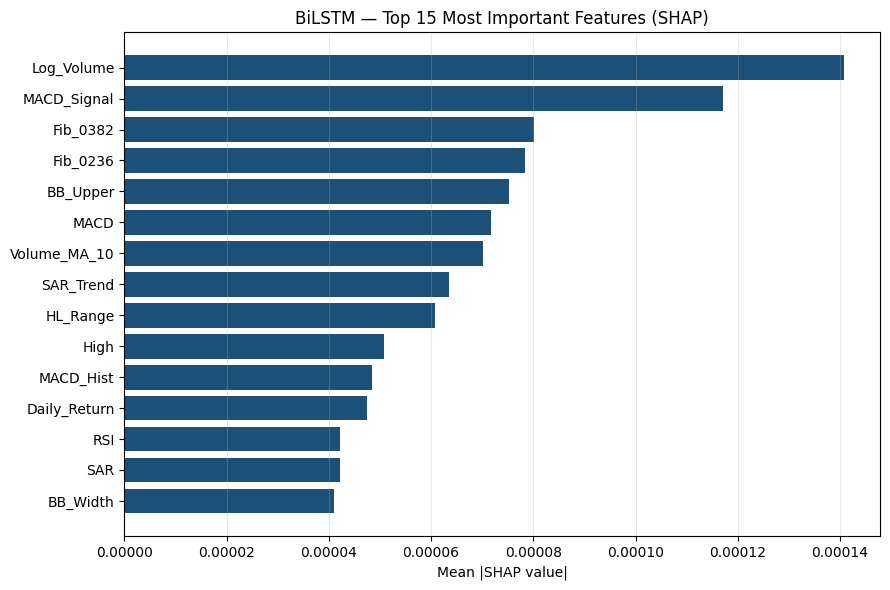

Saved: /content/drive/MyDrive/DMIF/models/shap_feature_importance.png


In [ ]:
top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features['feature'][::-1], top_features['importance'][::-1], color='#1C5078')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'BiLSTM — Top {top_n} Most Important Features (SHAP)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

plot_path = f'{MODELS_DIR}/shap_feature_importance.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")

# Plot — SHAP Importance Over Time (which days in the 30-day window matter most)


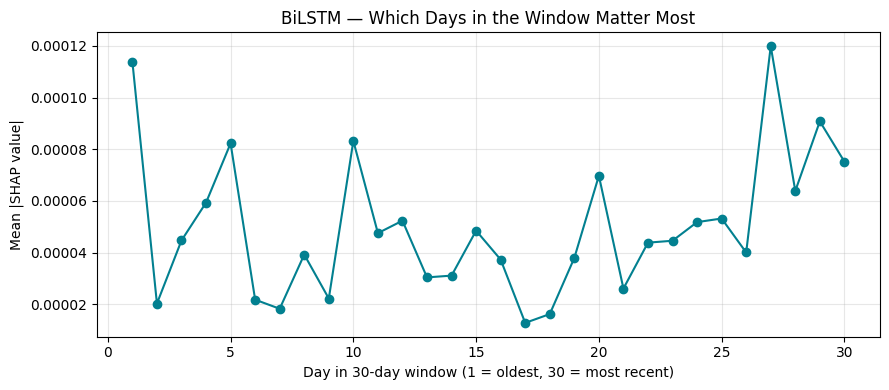

Saved: /content/drive/MyDrive/DMIF/models/shap_timestep_importance.png


In [ ]:
# Mean absolute importance per timestep, across all features and samples
timestep_importance = np.abs(shap_values).mean(axis=(0, 2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, SEQ_LEN+1), timestep_importance, marker='o', color='#028090')
ax.set_xlabel('Day in 30-day window (1 = oldest, 30 = most recent)')
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('BiLSTM — Which Days in the Window Matter Most')
ax.grid(alpha=0.3)
plt.tight_layout()

plot_path = f'{MODELS_DIR}/shap_timestep_importance.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")

# SHAP Summary Plot (standard SHAP beeswarm, flattened)


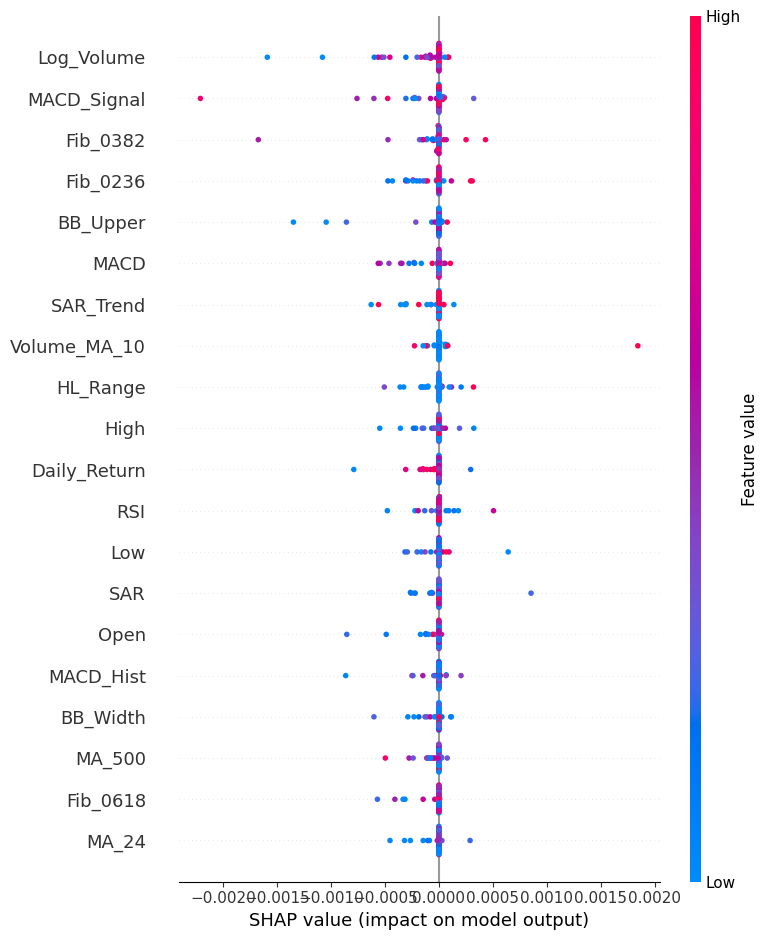

Saved: /content/drive/MyDrive/DMIF/models/shap_summary_plot.png


In [ ]:
# Use the last timestep of each sequence as the representative feature snapshot,
# paired with the SHAP values aggregated across time for that sample
last_step_features = X_explain[:, -1, :]                 # (n_samples, n_features)
shap_values_agg     = shap_values.mean(axis=1)            # (n_samples, n_features) — mean over time

shap.summary_plot(
    shap_values_agg,
    last_step_features,
    feature_names=LSTM_FEATURES,
    show=False
)
plt.tight_layout()
plot_path = f'{MODELS_DIR}/shap_summary_plot.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_path}")

# Save SHAP Results

In [ ]:
import json

shap_results = {
    'model'                : 'bilstm',
    'n_background'         : int(len(X_background)),
    'n_explained'          : int(len(X_explain)),
    'feature_importance'   : importance_df.to_dict(orient='records'),
    'top_5_features'       : importance_df.head(5)['feature'].tolist(),
    'timestep_importance'  : timestep_importance.tolist(),
}

results_path = f'{MODELS_DIR}/shap_results.json'
with open(results_path, 'w') as f:
    json.dump(shap_results, f, indent=2)

print(f"SHAP results saved: {results_path}")
print()
print("Top 5 most important features for BiLSTM predictions:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['feature']:<15} importance={row['importance']:.5f}")

SHAP results saved: /content/drive/MyDrive/DMIF/models/shap_results.json

Top 5 most important features for BiLSTM predictions:
  1. Log_Volume      importance=0.00014
  2. MACD_Signal     importance=0.00012
  3. Fib_0382        importance=0.00008
  4. Fib_0236        importance=0.00008
  5. BB_Upper        importance=0.00008
